# Policy gradient methods cont.
### REINFORCE with baseline and actor-critic methods
RLDMUU, UniNE 2026, jakub.tluczek@unine.ch

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

First, let's start with setting up PyTorch. As usual, we get the device on which we will compute everything, and also we will set the random seed to make the results reproducible:

In [5]:
torch.manual_seed(123)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(123)

In [6]:
# running mean function for the purpose of visualization
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

### REINFORCE WITH BASELINE

Last time we've seen how to implement REINFORCE algorithm, and how standardizing the returns $G$ made learning more stable. Another way to stabilize the learning process by reducing variance is to use some baseline algorithm $b(s)$, which would give us the expected return at state $s$. We can then use another parametrized, differentiable function to approximate the value at a given state. We can reuse the policy $\pi(a|s, \bf{\theta})$ from the previous exercise, while adding a state value function $\hat{v}(s, \bf{w})$, with its own parameters and separate learning rates $\alpha_\theta$ and $\alpha_{\bf{w}}$. Then, just as it was the case with previous exercise, for each episode we collect its trajectory $\tau$ and compute the following:

- generate a trajectory $\tau$ following policy $\pi(\cdot | \cdot, \theta)$
- for each $t$ in $\tau$:
    - $G_t \leftarrow \sum_{k=t+1}^{T} \gamma^{k-t-1} r_k$

Now however, instead of updating the network with discounted rewards in the future, we calculate the advantage term $\delta$ for each timestep $t$:

- $\delta \leftarrow G - \hat{v}(s_t, \bf{w})$

Then value network might be optimized with respect to the advantage term, while the update of the the policy network is conducted as follows:

- $\theta \leftarrow \theta + \alpha_\theta \gamma^t \delta \nabla ln \pi(a_t | s_t, \theta)$

In [7]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_dim_size):
        super(PolicyNetwork, self).__init__()
        # 2 fully connected layers
        self.linear1 = nn.Linear(n_inputs, hidden_dim_size)
        self.linear2 = nn.Linear(hidden_dim_size, n_outputs)

    def forward(self, state):
        x = F.relu(self.linear1(state))
        # instead of returning one output, let's return logπ together with π
        probs = F.softmax(self.linear2(x), dim=-1)
        log_probs = torch.log(probs)

        return probs, log_probs

In [8]:
# Value network: state -> scalar V(s)
class ValueNetwork(nn.Module):
    def __init__(self, num_states, hidden_dim):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(num_states, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        value = self.fc2(x)
        return value

In [9]:
# Initialize policy and value networks with their own optimizers
policy = PolicyNetwork(n_inputs=4, n_outputs=2, hidden_dim_size=128).to(device)
value = ValueNetwork(num_states=4, hidden_dim=128).to(device)
policy_optimizer = torch.optim.Adam(params=policy.parameters(), lr=1e-3)
value_optimizer = torch.optim.Adam(params=value.parameters(), lr=1e-3)

We are still going to use the `CartPole` environment:

In [10]:
env = gym.make('CartPole-v1')

REINFORCE with baseline main loop:

In [11]:
NUM_TRAJECTORIES = 2000
MAX_EPISODE_LENGTH = 500
gamma = 0.9
# placeholders for rewards for each episode
rewards = []
policy_losses = []
value_losses = []
# iterating through trajectories
for tau in tqdm(range(NUM_TRAJECTORIES)):
    # resetting the environment
    state, info = env.reset()
    # setting done to False for while loop 
    done = False
    # storing trajectory and logπ(a_t|s_t, θ)
    transition_buffer = []
    log_probs = []
    state_values = []

    t = 0
    while done == False and t < MAX_EPISODE_LENGTH:
        # Play the episode and collect data
        state_tensor = torch.FloatTensor(state).to(device)
        probs, log_pi = policy(state_tensor)
        v = value(state_tensor)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        transition_buffer.append(reward)
        log_probs.append(log_pi[action])
        state_values.append(v.squeeze())

        state = next_state
        t += 1
    # logging the episode length as a cumulative reward
    rewards.append(t)
    returns = []
    for t_prime in range(t):
        # computing discounted rewards in future for every timestep
        G = 0
        for i, tick in enumerate(transition_buffer[t_prime:]):
            G += (gamma ** i) * tick
        returns.append(G)

    # turning the returns vector into a tensor
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    state_values = torch.stack(state_values)
    log_probs = torch.stack(log_probs)

    # advantage δ = G - v(s)
    deltas = returns - state_values

    # Value loss: MSE between predicted v(s) and the observed return G
    value_loss = F.mse_loss(state_values, returns)

    # Policy loss: -γ^t * δ * log π(a|s); detach δ so gradients flow only through log π
    discount_factors = torch.tensor(
        [gamma ** t_prime for t_prime in range(t)], dtype=torch.float32
    ).to(device)
    policy_loss = -(discount_factors * deltas.detach() * log_probs).sum()

    # Update value network
    value_optimizer.zero_grad()
    value_loss.backward()
    value_optimizer.step()

    # Update policy network
    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_optimizer.step()

    policy_losses.append(policy_loss.item())
    value_losses.append(value_loss.item())

100%|██████████| 2000/2000 [05:41<00:00,  5.86it/s]


Text(0.5, 1.0, 'REINFORCE with baseline cumulative rewards')

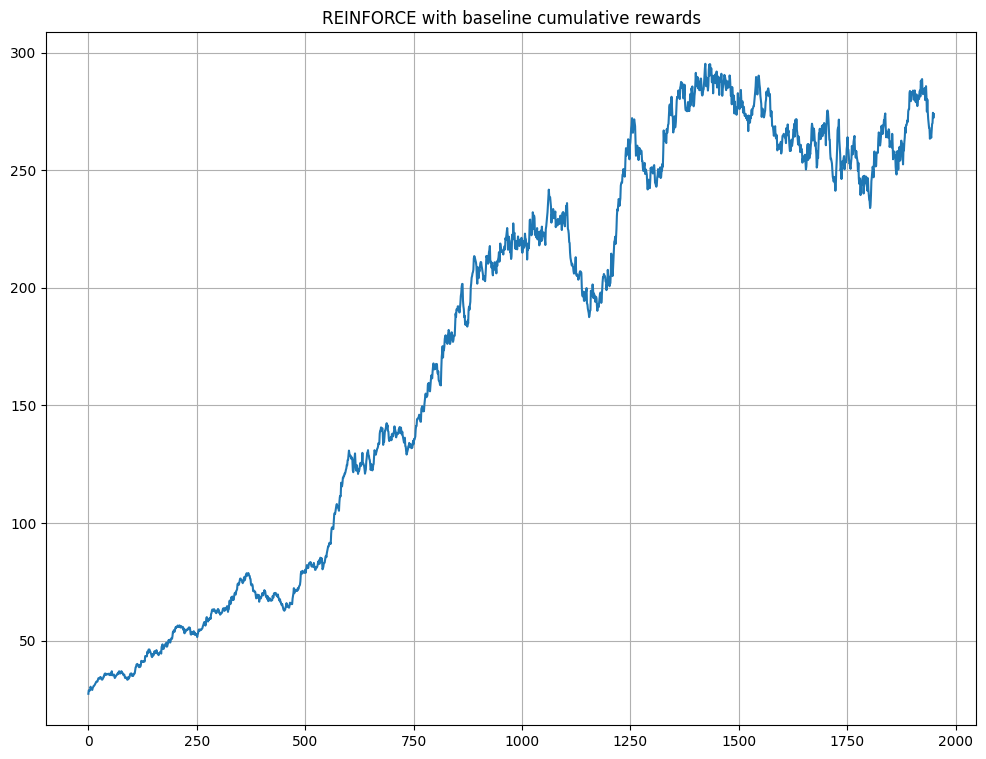

In [12]:
# visualize the results
plt.figure(figsize=(12,9))
plt.plot(running_mean(rewards, 50))
plt.grid()
plt.title("REINFORCE with baseline cumulative rewards")

### 1-step actor-critic

Another approach is to update the policy not at the end of each trajectory, but at each timestep using the 1 step return. Therefore when computing $\delta$ advantage term, we can use not the discounted rewards from all timesteps until the terminal state, but rather:

- $G_{t:t+1} \leftarrow r + \gamma \hat{v}(s', \bf{w})$
- $\delta \leftarrow G_{t:t+1} - \hat{v}(s, \bf{w})$

More specifically, we can use the existing policy to compute the advantage term in the online fashion:

- $\delta \leftarrow r + \gamma \hat{v}_{\pi}(s', \textbf{w}) - \hat{v}(s, \bf{w})$

Then we can update the value network with:

$\theta_v \leftarrow \theta_v + \alpha_\theta \delta^2 \nabla \hat{v}$

and the update for policy network:

$\theta_\pi \leftarrow \theta_\pi + \alpha_\theta \gamma^t \delta \nabla ln \pi(a_t | s_t, \theta)$


First let's reuse the policy and value networks from the previous exercise:

In [13]:
policy = PolicyNetwork(n_inputs=4, n_outputs=2, hidden_dim_size=128).to(device)
value = ValueNetwork(num_states=4, hidden_dim=128).to(device)
policy_optimizer = torch.optim.Adam(params=policy.parameters(), lr=1e-4)
value_optimizer = torch.optim.Adam(params=value.parameters(), lr=1e-3)

In [14]:
NUM_TRAJECTORIES = 1000
MAX_EPISODE_LENGTH = 500
gamma = 0.99
# placeholders for rewards for each episode
rewards = []
policy_losses = []
value_losses = []
# iterating through trajectories
for tau in tqdm(range(NUM_TRAJECTORIES)):
    # resetting the environment
    state, info = env.reset(seed=123)
    # setting done to False for while loop 
    done = False

    t = 0
    while done == False and t < MAX_EPISODE_LENGTH:
        # 1-step actor-critic update
        state_tensor = torch.FloatTensor(state).to(device)
        probs, log_pi = policy(state_tensor)
        v = value(state_tensor).squeeze()
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        next_state_tensor = torch.FloatTensor(next_state).to(device)
        with torch.no_grad():
            v_next = value(next_state_tensor).squeeze()
        # Bootstrap target: only use v(s') if the episode hasn't ended
        target = reward + gamma * v_next * (0.0 if done else 1.0)

        # TD error / advantage
        delta = target - v

        # Value loss: δ^2 (MSE on the TD target)
        value_loss = delta.pow(2)

        # Policy loss: -γ^t * δ * log π(a|s); detach δ for the policy update
        policy_loss = -(gamma ** t) * delta.detach() * log_pi[action]

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        policy_losses.append(policy_loss.item())
        value_losses.append(value_loss.item())

        state = next_state
        t += 1
    rewards.append(t)

100%|██████████| 1000/1000 [08:01<00:00,  2.08it/s]


Text(0.5, 1.0, '1-step actor-critic cumulative rewards')

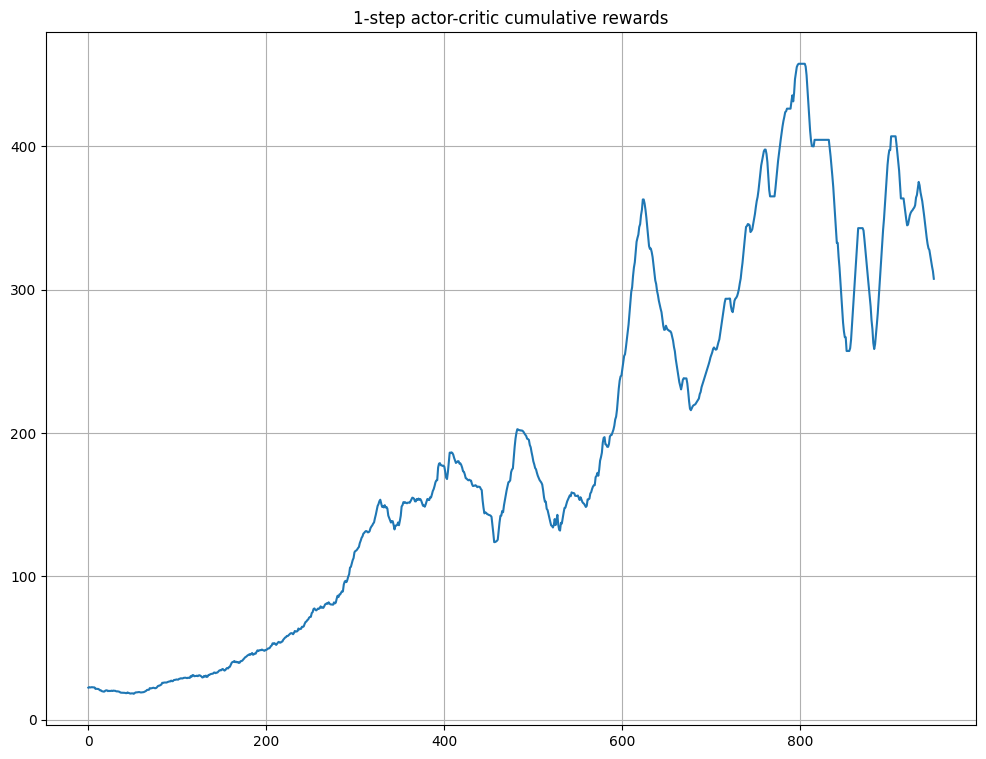

In [15]:
# visualize the results
plt.figure(figsize=(12,9))
plt.plot(running_mean(rewards, 50))
plt.grid()
plt.title("1-step actor-critic cumulative rewards")